# Audio Feature Engineering & EDA — PodcastFillers / STT Audio Dataset

Notebook ini terpisah dari notebook training model. Fokusnya adalah mengerjakan task:

1. Feature engineering audio:
   - MFCC
   - Delta MFCC
   - Delta-delta MFCC
   - Spectral centroid
   - Signal-to-noise ratio / SNR

2. EDA audio:
   - Kualitas audio berdasarkan SNR
   - Visualisasi waveform, spektrogram, dan MFCC
   - Distribusi durasi audio
   - Distribusi sampling rate
   - Distribusi label dan split
   - Keragaman sumber audio/podcast sebagai proxy variasi speaker

Notebook ini tidak melatih model. Output utamanya adalah analisis, visualisasi, dan file ringkasan fitur audio.

In [ ]:
# =========================
# OPTIONAL INSTALL
# Jalankan hanya jika library belum tersedia.
# =========================
# !pip install librosa soundfile pandas numpy matplotlib tqdm scipy scikit-learn

In [1]:
# =========================
# IMPORTS
# =========================
from pathlib import Path
import os
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import librosa
import librosa.display
import soundfile as sf

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("Imports OK")

c:\Users\andro\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 1. Konfigurasi Path Dataset

Sesuaikan `PROJECT_ROOT` jika lokasi folder kamu berbeda.

Struktur yang diharapkan:

```text
Filter Word Detection/
├── PodcastFillers.csv
└── extracted/
    └── PodcastFillers/
        └── audio/
            └── clip_wav/
                ├── train/
                ├── validation/
                └── test/
```

In [2]:
# =========================
# PATH CONFIG
# =========================

CANDIDATE_ROOTS = [
    Path(r"D:\KULIAH\Andro sems 6\Capstone\Filter Word Detection"),
    Path(r"C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection"),
    Path.cwd(),
]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "PodcastFillers.csv").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path(r"D:\KULIAH\Andro sems 6\Capstone\Filter Word Detection")

CSV_PATH = PROJECT_ROOT / "PodcastFillers.csv"
AUDIO_ROOT = PROJECT_ROOT / "extracted" / "PodcastFillers" / "audio" / "clip_wav"

OUTPUT_DIR = PROJECT_ROOT / "eda_audio_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CSV_PATH exists:", CSV_PATH.exists(), CSV_PATH)
print("AUDIO_ROOT exists:", AUDIO_ROOT.exists(), AUDIO_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection
CSV_PATH exists: True C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\PodcastFillers.csv
AUDIO_ROOT exists: True C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav
OUTPUT_DIR: C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\eda_audio_outputs


In [3]:
# =========================
# LOAD METADATA
# =========================

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV tidak ditemukan: {CSV_PATH}")

if not AUDIO_ROOT.exists():
    raise FileNotFoundError(f"AUDIO_ROOT tidak ditemukan: {AUDIO_ROOT}")

df = pd.read_csv(CSV_PATH)

print("CSV shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

CSV shape: (85803, 17)
Columns:
['clip_name', 'pfID', 'label_full_vocab', 'label_consolidated_vocab', 'podcast_filename', 'event_start_inepisode', 'event_end_inepisode', 'event_start_inclip', 'event_end_inclip', 'clip_start_inepisode', 'clip_end_inepisode', 'duration', 'confidence', 'n_annotators', 'episode_split_subset', 'clip_split_subset', 'pitch_cent']


,clip_name,pfID,label_full_vocab,label_consolidated_vocab,podcast_filename,event_start_inepisode,event_end_inepisode,event_start_inclip,event_end_inclip,clip_start_inepisode,clip_end_inepisode,duration,confidence,n_annotators,episode_split_subset,clip_split_subset,pitch_cent
0,00000.wav,0,Agree,NaN,The Voice of 5G_Episode 12_5G & IoT,1592.770048,1593.129984,0.320032,0.679968,1592.450016,1593.450016,0.359936,1.0,2,train,extra,2335.659222
1,00001.wav,1,Music,Music,UX Podcast_#198 Connected content with Carrie ...,2231.030000,2231.420000,0.305000,0.695000,2230.725000,2231.725000,0.390000,1.0,2,train,train,1466.040477
2,00002.wav,2,Uh,Uh,Education_Ep 1 - Handmade Dev Show 2017,1271.340000,1271.790080,0.274960,0.725040,1271.065040,1272.065040,0.450080,1.0,2,validation,validation,1249.172108
3,00003.wav,3,Breath,Breath,Design Story_025 Moira Cullen Design is Soft P...,2608.590029,2608.770000,0.410014,0.589986,2608.180014,2609.180014,0.179971,1.0,2,test,test,6181.648929
4,00004.wav,4,Music,Music,The Come Up Show_Lizzo shares stories about he...,1139.150029,1139.410000,0.370014,0.629986,1138.780014,1139.780014,0.259971,1.0,3,train,train,3465.520202


In [4]:
# =========================
# BUILD AUDIO PATHS
# =========================

required_cols = ["clip_name", "clip_split_subset", "label_full_vocab", "duration"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_cols}")

df["audio_path"] = df.apply(
    lambda row: AUDIO_ROOT / str(row["clip_split_subset"]) / str(row["clip_name"]),
    axis=1
)

df["audio_exists"] = df["audio_path"].apply(lambda p: p.exists())

print("Total rows:", len(df))
print("Audio exists:", int(df["audio_exists"].sum()))
print("Audio missing:", int((~df["audio_exists"]).sum()))

df_valid = df[df["audio_exists"]].copy().reset_index(drop=True)
df_valid.head()

Total rows: 85803
Audio exists: 85803
Audio missing: 0


,clip_name,pfID,label_full_vocab,label_consolidated_vocab,podcast_filename,event_start_inepisode,event_end_inepisode,event_start_inclip,event_end_inclip,clip_start_inepisode,clip_end_inepisode,duration,confidence,n_annotators,episode_split_subset,clip_split_subset,pitch_cent,audio_path,audio_exists
0,00000.wav,0,Agree,NaN,The Voice of 5G_Episode 12_5G & IoT,1592.770048,1593.129984,0.320032,0.679968,1592.450016,1593.450016,0.359936,1.0,2,train,extra,2335.659222,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,True
1,00001.wav,1,Music,Music,UX Podcast_#198 Connected content with Carrie ...,2231.030000,2231.420000,0.305000,0.695000,2230.725000,2231.725000,0.390000,1.0,2,train,train,1466.040477,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,True
2,00002.wav,2,Uh,Uh,Education_Ep 1 - Handmade Dev Show 2017,1271.340000,1271.790080,0.274960,0.725040,1271.065040,1272.065040,0.450080,1.0,2,validation,validation,1249.172108,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,True
3,00003.wav,3,Breath,Breath,Design Story_025 Moira Cullen Design is Soft P...,2608.590029,2608.770000,0.410014,0.589986,2608.180014,2609.180014,0.179971,1.0,2,test,test,6181.648929,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,True
4,00004.wav,4,Music,Music,The Come Up Show_Lizzo shares stories about he...,1139.150029,1139.410000,0.370014,0.629986,1138.780014,1139.780014,0.259971,1.0,3,train,train,3465.520202,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,True


## 2. Data Dictionary Ringkas

Cell ini membuat data dictionary otomatis dari kolom CSV dan menyimpannya sebagai CSV agar bisa dimasukkan ke laporan.

In [5]:
# =========================
# DATA DICTIONARY
# =========================

data_dictionary = []

for col in df.columns:
    sample_values = df[col].dropna().astype(str).head(5).tolist()
    data_dictionary.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "missing_count": int(df[col].isna().sum()),
        "missing_percentage": round(float(df[col].isna().mean() * 100), 3),
        "n_unique": int(df[col].nunique(dropna=True)),
        "example_values": " | ".join(sample_values),
    })

data_dictionary_df = pd.DataFrame(data_dictionary)
data_dictionary_path = OUTPUT_DIR / "audio_data_dictionary.csv"
data_dictionary_df.to_csv(data_dictionary_path, index=False)

print("Saved:", data_dictionary_path)
data_dictionary_df

Saved: C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\eda_audio_outputs\audio_data_dictionary.csv


,column,dtype,missing_count,missing_percentage,n_unique,example_values
0,clip_name,str,0,0.000,85803,00000.wav | 00001.wav | 00002.wav | 00003.wav ...
1,pfID,int64,0,0.000,85803,0 | 1 | 2 | 3 | 4
2,label_full_vocab,str,0,0.000,13,Agree | Music | Uh | Breath | Music
3,label_consolidated_vocab,str,9114,10.622,6,Music | Uh | Breath | Music | Um
4,podcast_filename,str,0,0.000,199,The Voice of 5G_Episode 12_5G & IoT | UX Podca...
5,event_start_inepisode,float64,0,0.000,83441,1592.770048 | 2231.0299999999843 | 1271.339999...
6,event_end_inepisode,float64,0,0.000,82929,1593.129984 | 2231.419999999984 | 1271.79008 |...
7,event_start_inclip,float64,0,0.000,36468,0.3200319999999692 | 0.3050000000000636 | 0.27...
8,event_end_inclip,float64,0,0.000,36462,0.6799680000000308 | 0.6949999999999363 | 0.72...
9,clip_start_inepisode,float64,0,0.000,85463,1592.4500159999998 | 2230.724999999984 | 1271....


## 3. EDA Metadata Dataset Audio

Bagian ini melihat distribusi:
- label
- split train/validation/test
- durasi event
- confidence anotasi
- jumlah annotator
- sumber podcast sebagai proxy keragaman speaker/sumber audio

In [6]:
# =========================
# BASIC DISTRIBUTION
# =========================

summary = {
    "total_rows": len(df),
    "valid_audio_files": int(df["audio_exists"].sum()),
    "missing_audio_files": int((~df["audio_exists"]).sum()),
    "n_labels_full_vocab": int(df["label_full_vocab"].nunique(dropna=True)),
    "n_clip_splits": int(df["clip_split_subset"].nunique(dropna=True)),
    "n_episode_splits": int(df["episode_split_subset"].nunique(dropna=True)) if "episode_split_subset" in df.columns else None,
    "duration_min": float(df["duration"].min()),
    "duration_mean": float(df["duration"].mean()),
    "duration_median": float(df["duration"].median()),
    "duration_max": float(df["duration"].max()),
}

summary_path = OUTPUT_DIR / "audio_dataset_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

summary

{'total_rows': 85803,
 'valid_audio_files': 85803,
 'missing_audio_files': 0,
 'n_labels_full_vocab': 13,
 'n_clip_splits': 4,
 'n_episode_splits': 3,
 'duration_min': 0.15,
 'duration_mean': 0.3381284783866487,
 'duration_median': 0.289923200019075,
 'duration_max': 2.0}

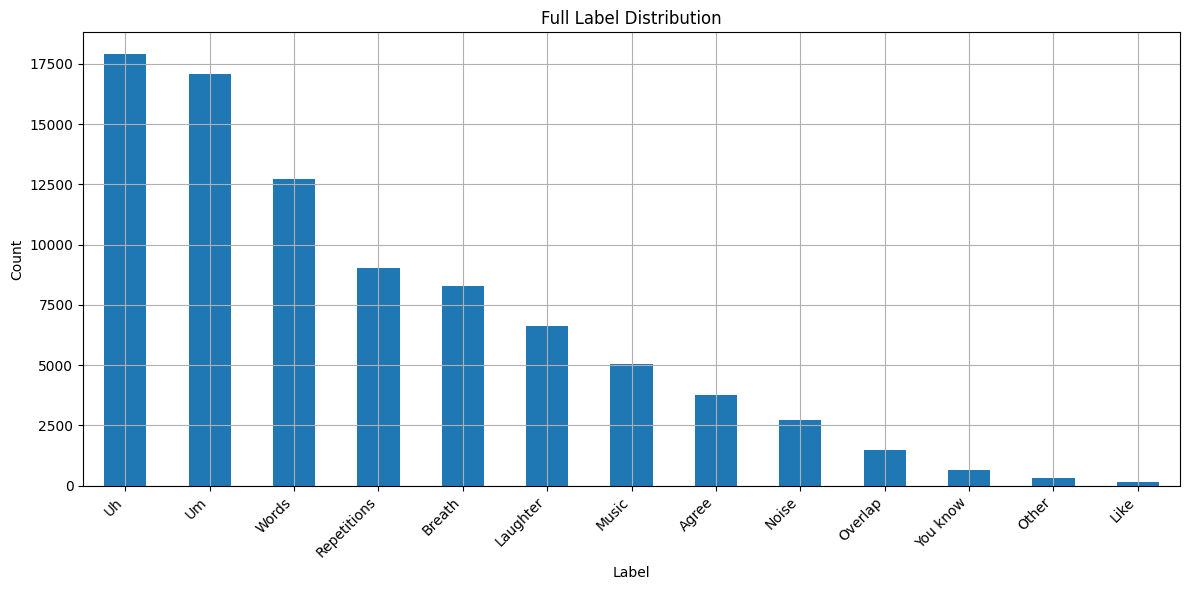

,count
label_full_vocab,
Uh,17907
Um,17078
Words,12709
Repetitions,9024
Breath,8288
Laughter,6623
Music,5060
Agree,3755
Noise,2735


In [7]:
# =========================
# LABEL DISTRIBUTION
# =========================

label_counts = df_valid["label_full_vocab"].value_counts()

plt.figure(figsize=(12, 6))
label_counts.plot(kind="bar")
plt.title("Full Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_distribution_full_vocab.png", dpi=150)
plt.show()

label_counts.to_frame("count")

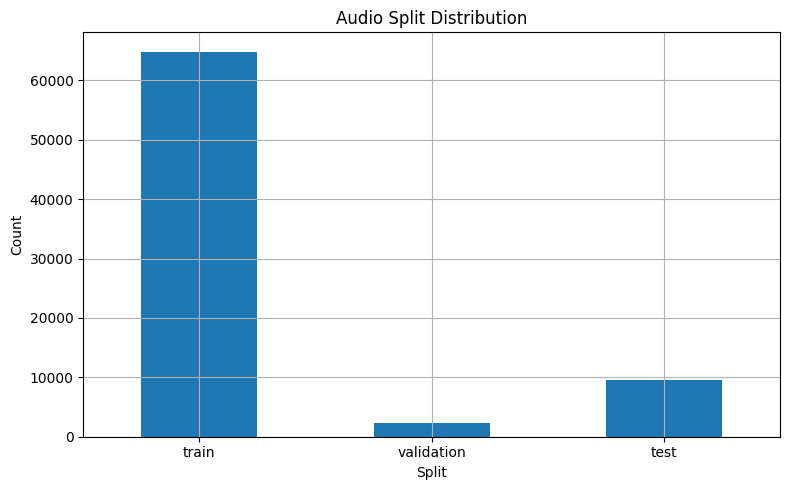

,count
clip_split_subset,
train,64835
validation,2379
test,9475


In [8]:
# =========================
# SPLIT DISTRIBUTION
# =========================

split_counts = df_valid["clip_split_subset"].value_counts().reindex(["train", "validation", "test"])

plt.figure(figsize=(8, 5))
split_counts.plot(kind="bar")
plt.title("Audio Split Distribution")
plt.xlabel("Split")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "split_distribution.png", dpi=150)
plt.show()

split_counts.to_frame("count")

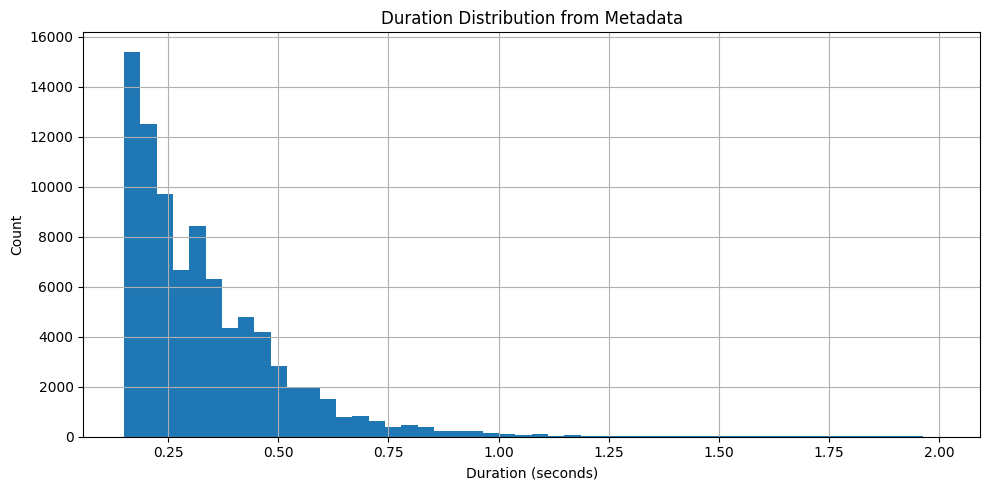

count    85803.000000
mean         0.338128
std          0.194980
min          0.150000
25%          0.200086
50%          0.289923
75%          0.419936
max          2.000000
Name: duration, dtype: float64

In [9]:
# =========================
# DURATION DISTRIBUTION
# =========================

plt.figure(figsize=(10, 5))
plt.hist(df_valid["duration"].dropna(), bins=50)
plt.title("Duration Distribution from Metadata")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "duration_distribution.png", dpi=150)
plt.show()

df_valid["duration"].describe()

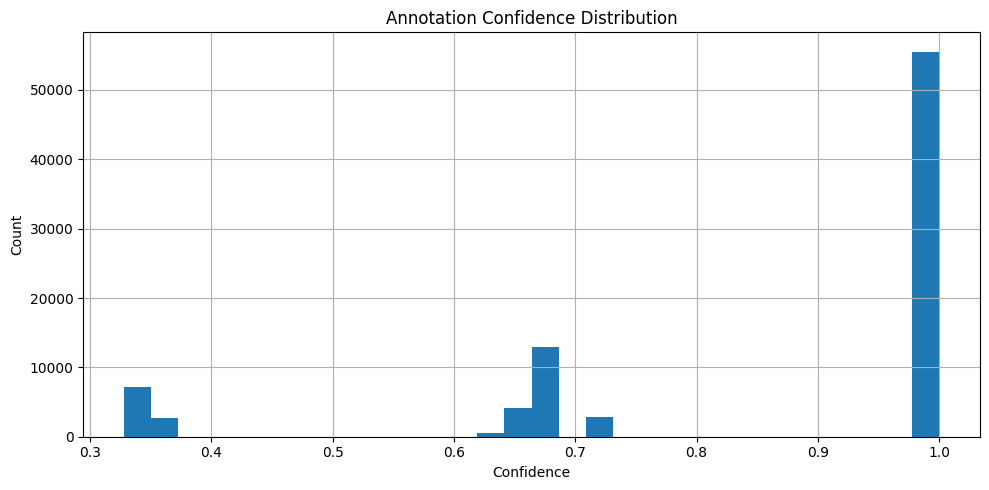

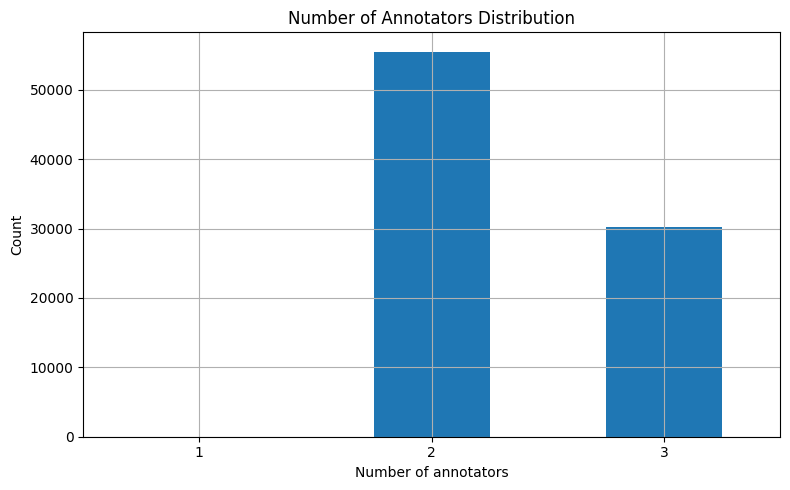

,confidence,n_annotators
count,85803.000000,85803.000000
mean,0.846923,2.352715
std,0.226896,0.478354
min,0.327900,1.000000
25%,0.670000,2.000000
50%,1.000000,2.000000
75%,1.000000,3.000000
max,1.000000,3.000000


In [10]:
# =========================
# CONFIDENCE AND ANNOTATORS
# =========================

if "confidence" in df_valid.columns:
    plt.figure(figsize=(10, 5))
    plt.hist(df_valid["confidence"].dropna(), bins=30)
    plt.title("Annotation Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "annotation_confidence_distribution.png", dpi=150)
    plt.show()

if "n_annotators" in df_valid.columns:
    annotator_counts = df_valid["n_annotators"].value_counts().sort_index()
    plt.figure(figsize=(8, 5))
    annotator_counts.plot(kind="bar")
    plt.title("Number of Annotators Distribution")
    plt.xlabel("Number of annotators")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "n_annotators_distribution.png", dpi=150)
    plt.show()

display_cols = [col for col in ["confidence", "n_annotators"] if col in df_valid.columns]
df_valid[display_cols].describe()

Unique podcast sources: 199


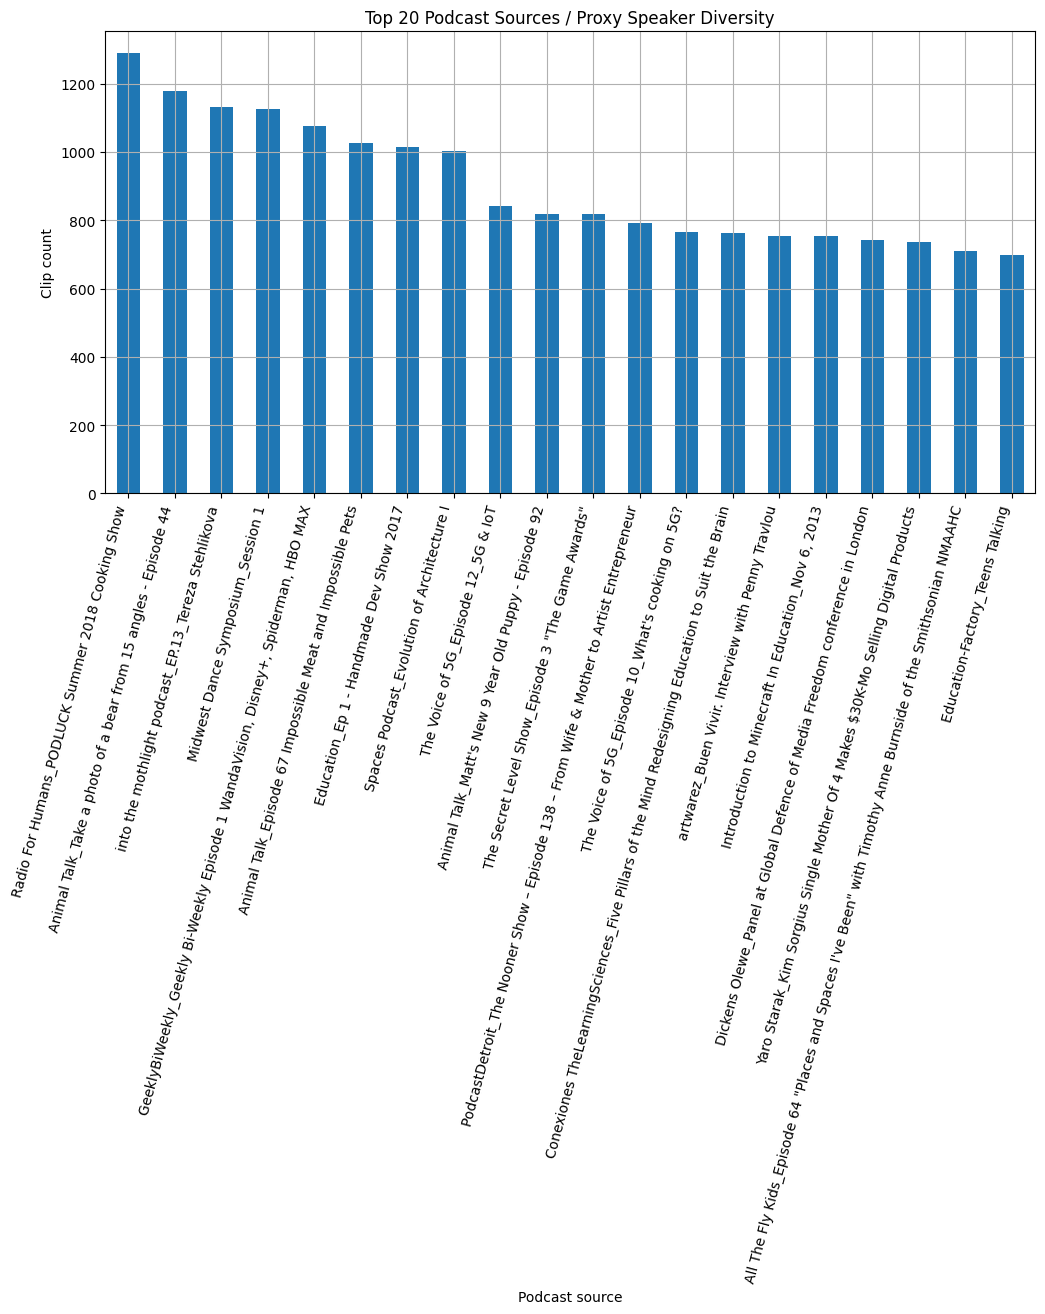

,count
podcast_filename,
Radio For Humans_PODLUCK Summer 2018 Cooking Show,1289
Animal Talk_Take a photo of a bear from 15 angles - Episode 44,1178
into the mothlight podcast_EP.13_Tereza Stehlikova,1131
Midwest Dance Symposium_Session 1,1125
"GeeklyBiWeekly_Geekly Bi-Weekly Episode 1 WandaVision, Disney+, Spiderman, HBO MAX",1078
Animal Talk_Episode 67 Impossible Meat and Impossible Pets,1027
Education_Ep 1 - Handmade Dev Show 2017,1015
Spaces Podcast_Evolution of Architecture I,1002
The Voice of 5G_Episode 12_5G & IoT,841


In [11]:
# =========================
# PODCAST SOURCE DIVERSITY
# Dataset ini tidak selalu punya speaker_id eksplisit.
# podcast_filename digunakan sebagai proxy untuk variasi sumber/speaker/accent.
# =========================

if "podcast_filename" in df_valid.columns:
    n_podcast_sources = df_valid["podcast_filename"].nunique()
    print("Unique podcast sources:", n_podcast_sources)

    top_podcasts = df_valid["podcast_filename"].value_counts().head(20)

    plt.figure(figsize=(12, 6))
    top_podcasts.plot(kind="bar")
    plt.title("Top 20 Podcast Sources / Proxy Speaker Diversity")
    plt.xlabel("Podcast source")
    plt.ylabel("Clip count")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "top_podcast_sources.png", dpi=150)
    plt.show()

    display(top_podcasts.to_frame("count"))
else:
    print("Kolom podcast_filename tidak ditemukan.")

## 4. Fungsi Feature Engineering Audio

Fitur yang dihitung:
- MFCC mean/std
- Delta MFCC mean/std
- Delta-delta MFCC mean/std
- Spectral centroid mean/std
- RMS energy
- Zero crossing rate
- SNR estimasi

Catatan SNR:
- Karena dataset tidak menyediakan noise-only segment eksplisit, SNR di sini adalah estimasi sederhana.
- Noise floor diperkirakan dari frame energi terendah.
- Cocok untuk EDA kualitas audio, bukan pengukuran lab yang absolut.

In [12]:
# =========================
# AUDIO FEATURE FUNCTIONS
# =========================

TARGET_SR = 16000
N_MFCC = 13
N_FFT = 512
HOP_LENGTH = 160
WIN_LENGTH = 400


def load_audio_mono(path, sr=TARGET_SR):
    y, loaded_sr = librosa.load(path, sr=sr, mono=True)
    if len(y) == 0:
        raise ValueError("Audio kosong.")
    y = y.astype(np.float32)
    return y, loaded_sr


def estimate_snr_db(y, frame_length=2048, hop_length=512, noise_percentile=10):
    if len(y) < frame_length:
        pad_width = frame_length - len(y)
        y = np.pad(y, (0, pad_width))

    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    signal_power = np.mean(y ** 2) + 1e-12
    noise_floor = np.percentile(rms, noise_percentile)
    noise_power = (noise_floor ** 2) + 1e-12
    snr_db = 10 * np.log10(signal_power / noise_power)
    return float(snr_db)


def extract_audio_features(audio_path):
    y, sr = load_audio_mono(audio_path, sr=TARGET_SR)

    duration_audio = librosa.get_duration(y=y, sr=sr)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    )

    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )[0]

    rms = librosa.feature.rms(
        y=y,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH
    )[0]

    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH
    )[0]

    snr_db = estimate_snr_db(y)

    features = {
        "audio_duration_sec": float(duration_audio),
        "sample_rate": int(sr),
        "snr_db": float(snr_db),
        "spectral_centroid_mean": float(np.mean(spectral_centroid)),
        "spectral_centroid_std": float(np.std(spectral_centroid)),
        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "zcr_mean": float(np.mean(zcr)),
        "zcr_std": float(np.std(zcr)),
    }

    for i in range(N_MFCC):
        features[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        features[f"mfcc_{i+1}_std"] = float(np.std(mfcc[i]))
        features[f"delta_mfcc_{i+1}_mean"] = float(np.mean(delta_mfcc[i]))
        features[f"delta_mfcc_{i+1}_std"] = float(np.std(delta_mfcc[i]))
        features[f"delta2_mfcc_{i+1}_mean"] = float(np.mean(delta2_mfcc[i]))
        features[f"delta2_mfcc_{i+1}_std"] = float(np.std(delta2_mfcc[i]))

    return features


print("Feature functions ready.")

Feature functions ready.


## 5. Ekstraksi Fitur untuk Sampel Dataset

Supaya efisien, default notebook mengambil sampel maksimal 5000 audio.  
Jika ingin semua data, ubah `MAX_FEATURE_FILES = None`.

In [22]:
# =========================
# FEATURE EXTRACTION CONFIG
# =========================

MAX_FEATURE_FILES = None  # Ubah ke None jika ingin memproses semua audio.
RANDOM_STATE = 42

if MAX_FEATURE_FILES is None:
    feature_df_source = df_valid.copy()
else:
    n_labels = max(df_valid["label_full_vocab"].nunique(), 1)
    per_label = max(1, MAX_FEATURE_FILES // n_labels)
    feature_df_source = (
        df_valid
        .groupby("label_full_vocab", group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), per_label), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

print("Total audio yang akan diproses:", len(feature_df_source))
feature_df_source[["clip_name", "clip_split_subset", "label_full_vocab", "audio_path"]].head()

Total audio yang akan diproses: 85803


,clip_name,clip_split_subset,label_full_vocab,audio_path
0,00000.wav,extra,Agree,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
1,00001.wav,train,Music,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
2,00002.wav,validation,Uh,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
3,00003.wav,test,Breath,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
4,00004.wav,train,Music,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...


In [23]:
# =========================
# EXTRACT FEATURES
# =========================

feature_rows = []

for _, row in tqdm(feature_df_source.iterrows(), total=len(feature_df_source)):
    audio_path = row["audio_path"]

    try:
        feats = extract_audio_features(audio_path)
        feats.update({
            "clip_name": row["clip_name"],
            "clip_split_subset": row["clip_split_subset"],
            "episode_split_subset": row.get("episode_split_subset", None),
            "label_full_vocab": row["label_full_vocab"],
            "label_consolidated_vocab": row.get("label_consolidated_vocab", None),
            "podcast_filename": row.get("podcast_filename", None),
            "metadata_duration": row.get("duration", np.nan),
            "confidence": row.get("confidence", np.nan),
            "n_annotators": row.get("n_annotators", np.nan),
            "audio_path": str(audio_path),
            "feature_error": None,
        })
    except Exception as e:
        feats = {
            "clip_name": row.get("clip_name", None),
            "clip_split_subset": row.get("clip_split_subset", None),
            "label_full_vocab": row.get("label_full_vocab", None),
            "audio_path": str(audio_path),
            "feature_error": str(e),
        }

    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)

features_path = OUTPUT_DIR / "audio_feature_engineering_summary.csv"
features_df.to_csv(features_path, index=False)

print("Saved:", features_path)
print("Feature shape:", features_df.shape)
print("Errors:", features_df["feature_error"].notna().sum() if "feature_error" in features_df.columns else 0)

features_df.head()

100%|██████████| 85803/85803 [18:53<00:00, 75.68it/s]  


Saved: C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\eda_audio_outputs\audio_feature_engineering_summary.csv
Feature shape: (85803, 98)
Errors: 0


,audio_duration_sec,sample_rate,snr_db,spectral_centroid_mean,spectral_centroid_std,rms_mean,rms_std,zcr_mean,zcr_std,mfcc_1_mean,...,clip_split_subset,episode_split_subset,label_full_vocab,label_consolidated_vocab,podcast_filename,metadata_duration,confidence,n_annotators,audio_path,feature_error
0,1.0,16000,10.079220,1216.953499,996.580891,0.031467,0.021453,0.088761,0.094659,-500.974548,...,extra,train,Agree,NaN,The Voice of 5G_Episode 12_5G & IoT,0.359936,1.0,2,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,None
1,1.0,16000,3.452782,2455.741600,623.754037,0.043759,0.016840,0.157894,0.113443,-334.743225,...,train,train,Music,Music,UX Podcast_#198 Connected content with Carrie ...,0.390000,1.0,2,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,None
2,1.0,16000,24.782000,1534.456163,859.044631,0.029964,0.027516,0.118735,0.110498,-474.431671,...,validation,validation,Uh,Uh,Education_Ep 1 - Handmade Dev Show 2017,0.450080,1.0,2,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,None
3,1.0,16000,22.145002,1724.301872,1097.007078,0.040543,0.051096,0.142017,0.149396,-535.067383,...,test,test,Breath,Breath,Design Story_025 Moira Cullen Design is Soft P...,0.179971,1.0,2,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,None
4,1.0,16000,3.540769,1480.059236,771.432520,0.064633,0.019038,0.090598,0.081737,-349.631195,...,train,train,Music,Music,The Come Up Show_Lizzo shares stories about he...,0.259971,1.0,3,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...,None


## 6. EDA Hasil Feature Engineering

Bagian ini menganalisis fitur audio yang sudah diekstrak:
- distribusi SNR
- distribusi spectral centroid
- perbandingan SNR antar label
- ringkasan fitur per label

In [24]:
# =========================
# CLEAN FEATURE DF
# =========================

features_clean = features_df[features_df.get("feature_error").isna()].copy()

print("Features clean:", features_clean.shape)
features_clean[["label_full_vocab", "snr_db", "spectral_centroid_mean", "audio_duration_sec"]].describe()

Features clean: (85803, 98)


,snr_db,spectral_centroid_mean,audio_duration_sec
count,85803.000000,85803.000000,85803.000000
mean,17.406249,1635.371585,0.999899
std,11.533664,466.378828,0.005377
min,0.529278,117.231394,0.582375
25%,8.678725,1302.859740,1.000000
50%,15.072688,1596.113896,1.000000
75%,23.396210,1919.228639,1.000000
max,98.506918,4739.249534,1.000000


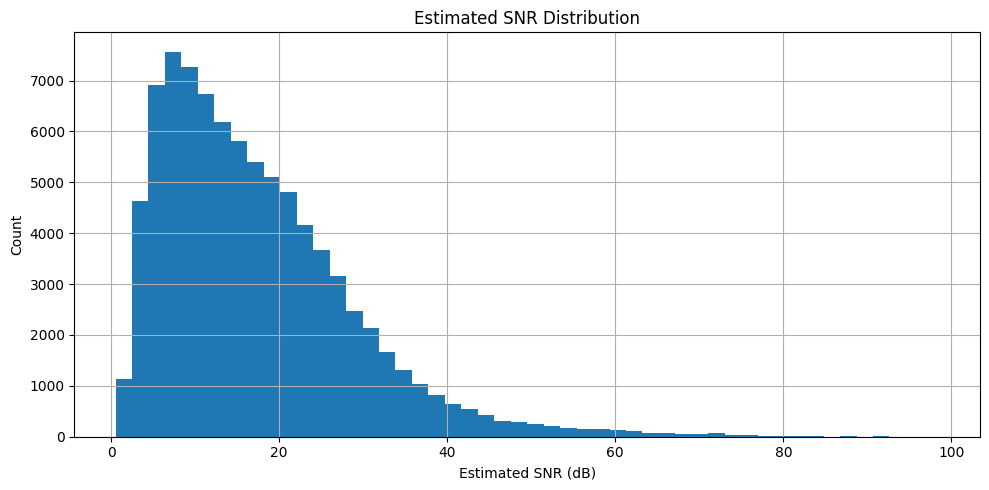

count    85803.000000
mean        17.406249
std         11.533664
min          0.529278
25%          8.678725
50%         15.072688
75%         23.396210
max         98.506918
Name: snr_db, dtype: float64

In [25]:
# =========================
# SNR DISTRIBUTION
# =========================

plt.figure(figsize=(10, 5))
plt.hist(features_clean["snr_db"].dropna(), bins=50)
plt.title("Estimated SNR Distribution")
plt.xlabel("Estimated SNR (dB)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "snr_distribution.png", dpi=150)
plt.show()

features_clean["snr_db"].describe()

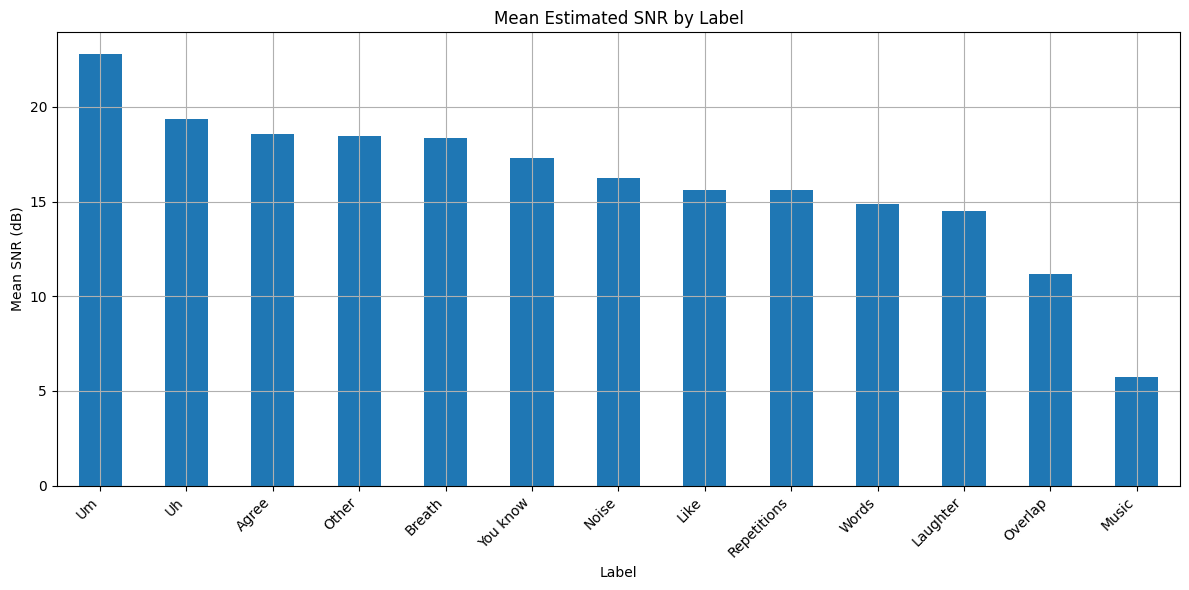

,count,mean,median,std,min,max
label_full_vocab,,,,,,
Um,17078,22.790274,21.678159,12.087872,1.507789,96.068047
Uh,17907,19.371377,17.363221,12.309049,0.790551,98.506918
Agree,3755,18.537480,16.464134,10.634405,1.202470,76.456057
Other,315,18.470650,16.225600,11.244965,2.575970,79.334258
Breath,8288,18.350388,17.110597,8.464777,0.819740,83.064449
You know,668,17.281257,12.721351,13.455159,1.392667,91.834830
Noise,2735,16.249351,14.797436,10.333432,0.763457,92.210839
Like,157,15.614458,12.342755,11.103455,2.683514,69.188453
Repetitions,9024,15.590793,12.733225,10.472685,1.209002,94.666652


In [26]:
# =========================
# SNR BY LABEL
# =========================

snr_by_label = (
    features_clean
    .groupby("label_full_vocab")["snr_db"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

plt.figure(figsize=(12, 6))
snr_by_label["mean"].plot(kind="bar")
plt.title("Mean Estimated SNR by Label")
plt.xlabel("Label")
plt.ylabel("Mean SNR (dB)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mean_snr_by_label.png", dpi=150)
plt.show()

snr_by_label

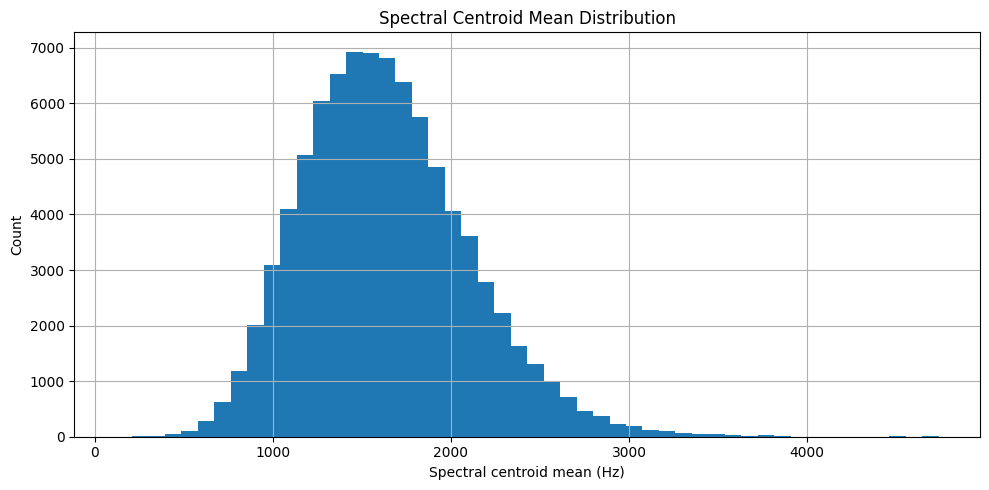

,count,mean,median,std
label_full_vocab,,,,
Breath,8288,1980.716105,1953.768744,458.633076
Laughter,6623,1833.599422,1800.471662,396.475615
Music,5060,1738.468622,1749.041856,553.182988
Noise,2735,1653.669277,1580.189434,588.985519
Overlap,1484,1650.006702,1605.772280,369.625717
Words,12709,1632.401982,1584.870982,439.856944
Like,157,1591.889451,1541.187312,452.097644
Uh,17907,1586.008014,1543.341866,426.661766
Repetitions,9024,1551.043884,1481.970952,487.882391


In [27]:
# =========================
# SPECTRAL CENTROID DISTRIBUTION
# =========================

plt.figure(figsize=(10, 5))
plt.hist(features_clean["spectral_centroid_mean"].dropna(), bins=50)
plt.title("Spectral Centroid Mean Distribution")
plt.xlabel("Spectral centroid mean (Hz)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spectral_centroid_distribution.png", dpi=150)
plt.show()

centroid_by_label = (
    features_clean
    .groupby("label_full_vocab")["spectral_centroid_mean"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

centroid_by_label

In [28]:
# =========================
# FEATURE SUMMARY BY LABEL
# =========================

summary_cols = [
    "snr_db",
    "spectral_centroid_mean",
    "rms_mean",
    "zcr_mean",
    "audio_duration_sec",
] + [f"mfcc_{i}_mean" for i in range(1, 14)]

feature_summary_by_label = (
    features_clean
    .groupby("label_full_vocab")[summary_cols]
    .mean()
    .round(4)
)

feature_summary_path = OUTPUT_DIR / "feature_summary_by_label.csv"
feature_summary_by_label.to_csv(feature_summary_path)

print("Saved:", feature_summary_path)
feature_summary_by_label

Saved: C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\eda_audio_outputs\feature_summary_by_label.csv


,snr_db,spectral_centroid_mean,rms_mean,zcr_mean,audio_duration_sec,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean
label_full_vocab,,,,,,,,,,,,,,,,,,
Agree,18.5375,1487.5105,0.0472,0.1067,1.0000,-475.4556,105.3215,5.7066,32.7053,4.6136,2.9735,-5.5984,-2.4330,-3.7429,-2.5193,-6.8685,-3.7696,-4.5470
Breath,18.3504,1980.7161,0.0636,0.1760,1.0000,-410.7424,74.2956,-9.3707,32.3508,-5.3156,-1.6503,-10.2815,-2.1785,-3.6525,-2.8986,-7.1278,-1.3466,-2.1290
Laughter,14.4906,1833.5994,0.0746,0.1477,0.9999,-382.4414,83.1468,-18.1068,20.1355,-4.2557,-6.4346,-12.0702,-7.2049,-1.6889,-3.1047,-9.2091,-2.7081,-4.3690
Like,15.6145,1591.8895,0.0651,0.1223,1.0000,-429.4181,101.9796,-3.9895,28.7792,-7.1289,-6.7719,-14.0301,-7.8502,-6.6444,-5.4589,-6.2182,-4.8538,-4.7651
Music,5.7456,1738.4686,0.0608,0.1208,0.9993,-352.7141,93.6212,7.3846,19.8974,-0.7719,6.6048,-1.5838,4.4942,-0.7366,2.5684,-2.1793,1.9955,-2.9373
Noise,16.2494,1653.6693,0.0563,0.1260,0.9999,-438.0491,89.6032,3.9701,28.7729,3.2089,3.7798,-4.9218,0.4202,-3.7066,1.1643,-4.3375,0.4008,-2.5161
Other,18.4706,1508.2706,0.0518,0.1102,1.0000,-466.5676,106.7170,4.4781,32.4695,0.8544,-4.0440,-10.0995,-5.8326,-8.4078,-2.6198,-7.2679,-3.6102,-4.6317
Overlap,11.1810,1650.0067,0.1016,0.1258,1.0000,-341.7994,102.2514,-7.7368,27.8113,-9.7125,-9.4472,-15.0409,-9.8460,-7.9635,-5.4471,-7.9858,-5.2204,-6.6800
Repetitions,15.5908,1551.0439,0.0571,0.1189,0.9999,-452.6603,105.1987,9.3974,32.3677,2.1368,-2.9346,-11.1560,-7.6421,-9.2452,-3.8073,-7.3338,-3.7345,-5.5057


## 7. Visualisasi Waveform, Spectrogram, dan MFCC

Pilih satu audio sample untuk divisualisasikan. Secara default notebook mengambil satu contoh pertama dari data valid.

In [29]:
# =========================
# SELECT SAMPLE AUDIO
# =========================

sample_index = 0
sample_row = df_valid.iloc[sample_index]
sample_audio_path = sample_row["audio_path"]

print("Sample path:", sample_audio_path)
print("Label:", sample_row["label_full_vocab"])
print("Split:", sample_row["clip_split_subset"])

y, sr = load_audio_mono(sample_audio_path, sr=TARGET_SR)
print("Audio shape:", y.shape)
print("Sample rate:", sr)
print("Duration:", librosa.get_duration(y=y, sr=sr))

Sample path: C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav\extra\00000.wav
Label: Agree
Split: extra
Audio shape: (16000,)
Sample rate: 16000
Duration: 1.0


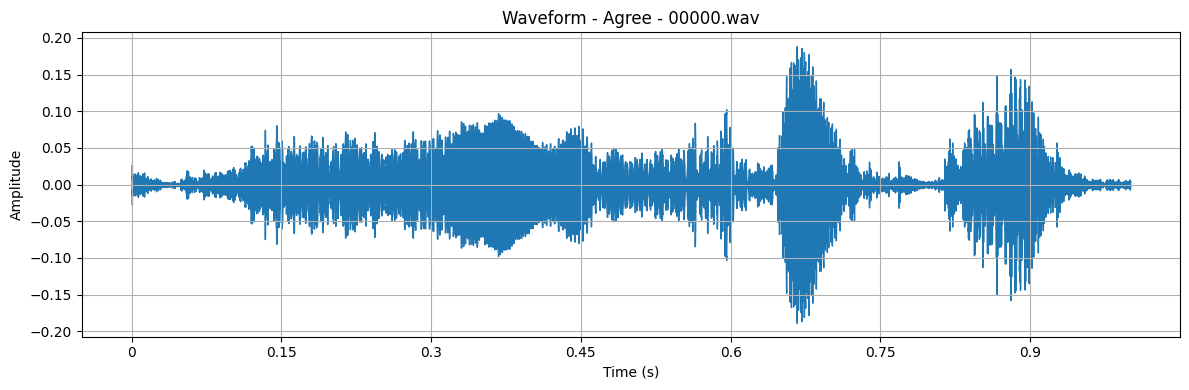

In [30]:
# =========================
# WAVEFORM
# =========================

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform - {sample_row['label_full_vocab']} - {sample_row['clip_name']}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_waveform.png", dpi=150)
plt.show()

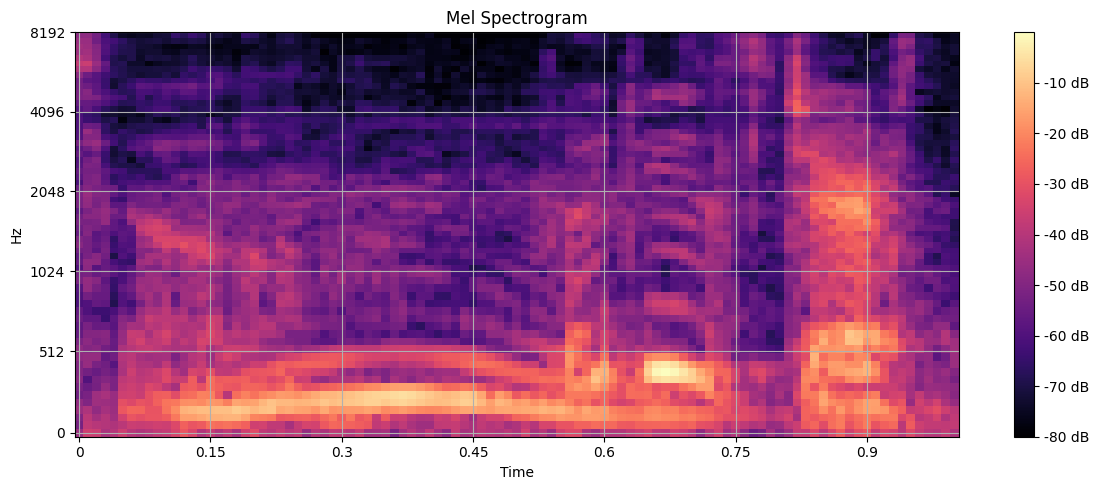

In [31]:
# =========================
# MEL SPECTROGRAM
# =========================

mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    win_length=WIN_LENGTH,
    n_mels=64,
    power=2.0
)

mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_mel_spectrogram.png", dpi=150)
plt.show()

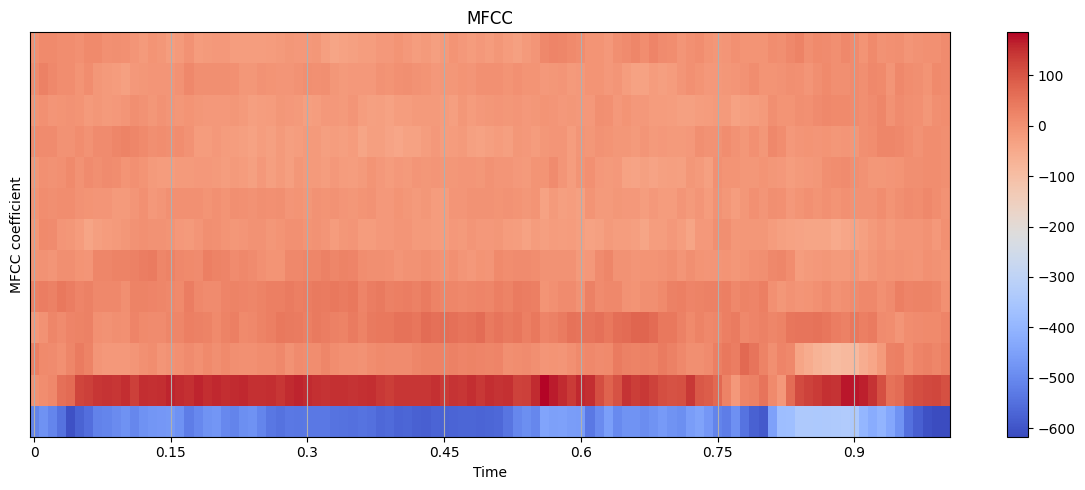

In [32]:
# =========================
# MFCC
# =========================

mfcc_sample = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=N_MFCC,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    win_length=WIN_LENGTH
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mfcc_sample,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time"
)
plt.colorbar()
plt.title("MFCC")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_mfcc.png", dpi=150)
plt.show()

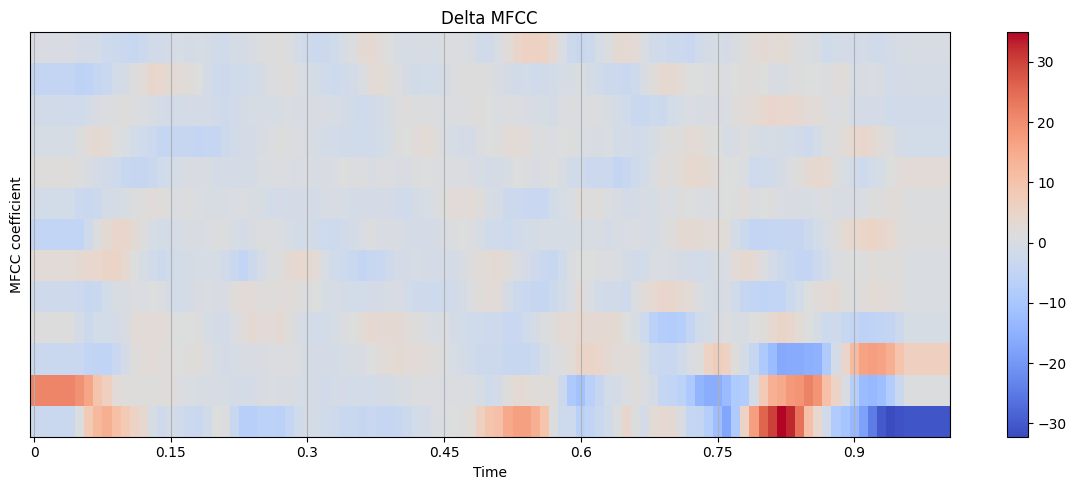

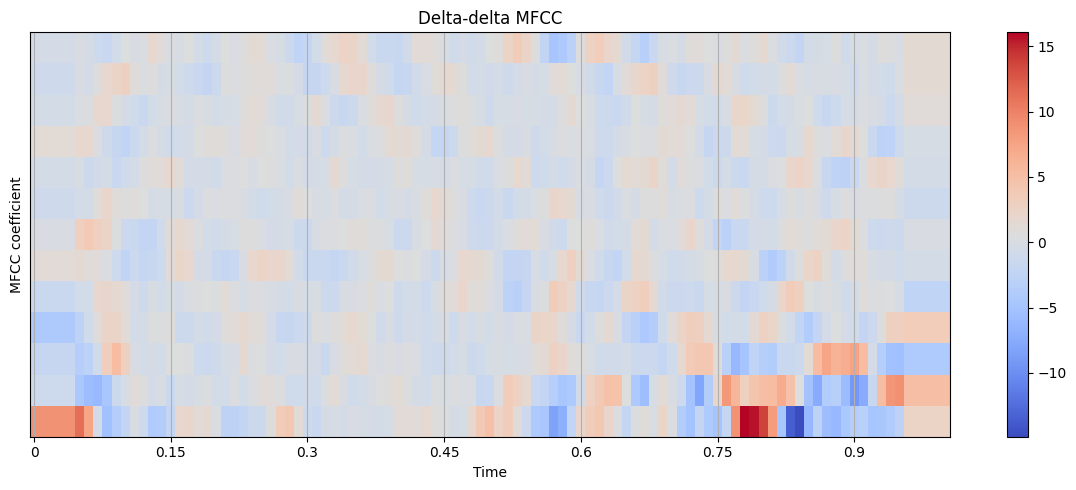

In [33]:
# =========================
# DELTA AND DELTA-DELTA MFCC
# =========================

delta_sample = librosa.feature.delta(mfcc_sample)
delta2_sample = librosa.feature.delta(mfcc_sample, order=2)

plt.figure(figsize=(12, 5))
librosa.display.specshow(delta_sample, sr=sr, hop_length=HOP_LENGTH, x_axis="time")
plt.colorbar()
plt.title("Delta MFCC")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_delta_mfcc.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
librosa.display.specshow(delta2_sample, sr=sr, hop_length=HOP_LENGTH, x_axis="time")
plt.colorbar()
plt.title("Delta-delta MFCC")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_delta2_mfcc.png", dpi=150)
plt.show()

## 8. Analisis Kualitas Audio dan Outlier

Cell ini menandai audio dengan:
- SNR rendah
- durasi sangat pendek/panjang
- fitur gagal diekstrak

In [34]:
# =========================
# AUDIO QUALITY FLAGS
# =========================

quality_df = features_df.copy()

quality_df["low_snr_flag"] = quality_df["snr_db"] < quality_df["snr_db"].quantile(0.10)
quality_df["very_short_flag"] = quality_df["audio_duration_sec"] < quality_df["audio_duration_sec"].quantile(0.05)
quality_df["very_long_flag"] = quality_df["audio_duration_sec"] > quality_df["audio_duration_sec"].quantile(0.95)
quality_df["feature_failed_flag"] = quality_df["feature_error"].notna() if "feature_error" in quality_df.columns else False

quality_cols = [
    "clip_name",
    "clip_split_subset",
    "label_full_vocab",
    "audio_duration_sec",
    "snr_db",
    "low_snr_flag",
    "very_short_flag",
    "very_long_flag",
    "feature_failed_flag",
    "audio_path",
]

quality_report = quality_df[quality_cols].copy()

quality_report_path = OUTPUT_DIR / "audio_quality_report.csv"
quality_report.to_csv(quality_report_path, index=False)

print("Saved:", quality_report_path)
print("Low SNR:", int(quality_report["low_snr_flag"].sum()))
print("Very short:", int(quality_report["very_short_flag"].sum()))
print("Very long:", int(quality_report["very_long_flag"].sum()))
print("Feature failed:", int(quality_report["feature_failed_flag"].sum()))

quality_report.sort_values("snr_db").head(20)

Saved: C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\eda_audio_outputs\audio_quality_report.csv
Low SNR: 8581
Very short: 42
Very long: 0
Feature failed: 0


,clip_name,clip_split_subset,label_full_vocab,audio_duration_sec,snr_db,low_snr_flag,very_short_flag,very_long_flag,feature_failed_flag,audio_path
67281,67281.wav,train,Music,1.0,0.529278,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
56221,56221.wav,train,Music,1.0,0.654498,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
667,00667.wav,train,Music,1.0,0.657431,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
19610,19610.wav,train,Music,1.0,0.712249,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
19872,19872.wav,train,Music,1.0,0.747282,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
64431,64431.wav,train,Music,1.0,0.754940,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
84067,84067.wav,train,Music,1.0,0.756112,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
19281,19281.wav,extra,Noise,1.0,0.763457,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
17615,17615.wav,test,Uh,1.0,0.790551,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...
64400,64400.wav,train,Music,1.0,0.799024,True,False,False,False,C:\KULIAH\Andro sems 6\Capstone\Filter Word De...


## 9. Kesimpulan Otomatis untuk Laporan

Cell ini menghasilkan teks ringkasan yang bisa kamu gunakan di laporan atau proposal.

In [35]:
# =========================
# AUTO SUMMARY TEXT
# =========================

n_audio = len(df_valid)
n_labels = df_valid["label_full_vocab"].nunique()
n_splits = df_valid["clip_split_subset"].nunique()
duration_mean = df_valid["duration"].mean()
duration_median = df_valid["duration"].median()

snr_mean = features_clean["snr_db"].mean()
snr_median = features_clean["snr_db"].median()
centroid_mean = features_clean["spectral_centroid_mean"].mean()

n_sources = df_valid["podcast_filename"].nunique() if "podcast_filename" in df_valid.columns else None

summary_text = f"""
Audio EDA Summary

Dataset valid berisi {n_audio:,} file audio dengan {n_labels} label unik dan {n_splits} split data.
Rata-rata durasi event berdasarkan metadata adalah {duration_mean:.3f} detik, dengan median {duration_median:.3f} detik.

Feature engineering dilakukan menggunakan MFCC, delta MFCC, delta-delta MFCC, spectral centroid, RMS energy, zero crossing rate, dan estimasi SNR.
Pada sampel fitur yang diproses, rata-rata estimasi SNR adalah {snr_mean:.3f} dB dan median SNR adalah {snr_median:.3f} dB.
Rata-rata spectral centroid adalah {centroid_mean:.3f} Hz.

Keragaman sumber audio dievaluasi menggunakan podcast_filename sebagai proxy speaker/source diversity.
Jumlah sumber podcast unik: {n_sources if n_sources is not None else "tidak tersedia"}.

File output yang dihasilkan:
- audio_data_dictionary.csv
- audio_dataset_summary.json
- audio_feature_engineering_summary.csv
- feature_summary_by_label.csv
- audio_quality_report.csv
- visualisasi waveform, mel spectrogram, MFCC, delta MFCC, dan delta-delta MFCC
"""

summary_report_path = OUTPUT_DIR / "audio_eda_summary_text.txt"
with open(summary_report_path, "w", encoding="utf-8") as f:
    f.write(summary_text.strip())

print(summary_text)
print("Saved:", summary_report_path)


Audio EDA Summary

Dataset valid berisi 85,803 file audio dengan 13 label unik dan 4 split data.
Rata-rata durasi event berdasarkan metadata adalah 0.338 detik, dengan median 0.290 detik.

Feature engineering dilakukan menggunakan MFCC, delta MFCC, delta-delta MFCC, spectral centroid, RMS energy, zero crossing rate, dan estimasi SNR.
Pada sampel fitur yang diproses, rata-rata estimasi SNR adalah 17.406 dB dan median SNR adalah 15.073 dB.
Rata-rata spectral centroid adalah 1635.372 Hz.

Keragaman sumber audio dievaluasi menggunakan podcast_filename sebagai proxy speaker/source diversity.
Jumlah sumber podcast unik: 199.

File output yang dihasilkan:
- audio_data_dictionary.csv
- audio_dataset_summary.json
- audio_feature_engineering_summary.csv
- feature_summary_by_label.csv
- audio_quality_report.csv
- visualisasi waveform, mel spectrogram, MFCC, delta MFCC, dan delta-delta MFCC

Saved: C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\eda_audio_outputs\audio_eda_summary_text.txt


## 10. Output Akhir

Setelah notebook selesai dijalankan, folder `eda_audio_outputs` akan berisi:

```text
audio_data_dictionary.csv
audio_dataset_summary.json
audio_feature_engineering_summary.csv
feature_summary_by_label.csv
audio_quality_report.csv
label_distribution_full_vocab.png
split_distribution.png
duration_distribution.png
snr_distribution.png
mean_snr_by_label.png
spectral_centroid_distribution.png
sample_waveform.png
sample_mel_spectrogram.png
sample_mfcc.png
sample_delta_mfcc.png
sample_delta2_mfcc.png
audio_eda_summary_text.txt
```

File tersebut bisa digunakan sebagai bukti EDA dan feature engineering audio untuk laporan.